In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [2]:
# Data

x = np.array([1,3,5,8,11,14,17,20]).reshape(-1,1)
y = np.array([10,15,22,35,50,65,72,75])

In [20]:
def poly_polynomial(degree,color,label):
    # create Feature
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    x_poly = poly.fit_transform(x)

    # Train Model
    model = LinearRegression()
    model.fit(x_poly,y)

    # Predict mooth urve for Plotting
    x_smooth = np.linspace(0,25,200).reshape(-1,1)
    x_smooth_poly = poly.transform(x_smooth)
    y_smooth = model.predict(x_smooth_poly)

    plt.plot(x_smooth,y_smooth, color=color, linewidth =3 , label=label )

    # Print Equations
    coeffs = model.coef_
    intercept = model.intercept_
    print(f"\n{label} Equation")
    eq = f"y={intercept:.2f}"
    for i , c in enumerate(coeffs):
        eq += f" + {c:.3f}*X^{i-1}"
    print(eq)
    return model,poly


Linear (degree 1) Equation
y=5.55 + 3.792*X^-1

Quadratic (degree 2) Equation
y=1.44 + 5.068*X^-1 + -0.062*X^0

Cubic (degree 3) Equation
y=9.18 + 0.555*X^-1 + 0.479*X^0 + -0.017*X^1


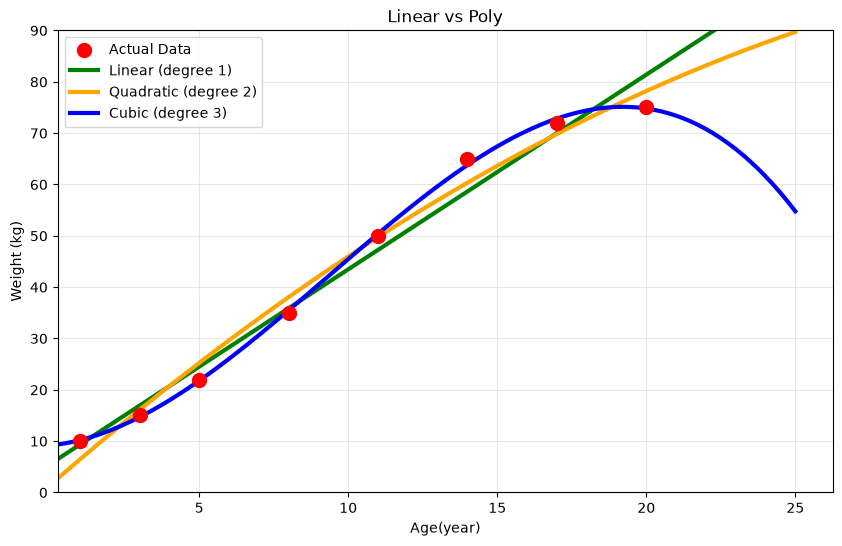

Predicted weight at age 25 = 54.8 kg


In [25]:
# Create a plot three
plt.figure(figsize=(10,6))
plt.scatter(x,y,color="red",s=100,label="Actual Data",zorder=5)

# Linear (Degree 1)

poly_polynomial(1,"green","Linear (degree 1)")

# Quadratic (degree 2)

poly_polynomial(2,"orange","Quadratic (degree 2)")

# Cubic (degree 3)

model_cubic , poly_cubic = poly_polynomial(3, "blue","Cubic (degree 3)")

plt.xlabel("Age(year)")
plt.ylabel("Weight (kg)")
plt.title("Linear vs Poly")
plt.legend()
plt.grid(True,alpha=0.3)
plt.ylim(0,90)
plt.xlim(0.25)
plt.show()

# Predict
age_25 = poly_cubic.transform([[25]])
weight_25 = model_cubic.predict(age_25)

print(f"Predicted weight at age 25 = {weight_25[0]:.1f} kg")